In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("bank.csv", sep=';')
print(df.head())


   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  


In [5]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None


In [7]:
print(df['y'].value_counts())

y
no     4000
yes     521
Name: count, dtype: int64


In [9]:
df.replace("unknown", df.mode().iloc[0], inplace=True)
print(df)

      age            job  marital  education default  balance housing loan  \
0      30     unemployed  married    primary      no     1787      no   no   
1      33       services  married  secondary      no     4789     yes  yes   
2      35     management   single   tertiary      no     1350     yes   no   
3      30     management  married   tertiary      no     1476     yes  yes   
4      59    blue-collar  married  secondary      no        0     yes   no   
...   ...            ...      ...        ...     ...      ...     ...  ...   
4516   33       services  married  secondary      no     -333     yes   no   
4517   57  self-employed  married   tertiary     yes    -3313     yes  yes   
4518   57     technician  married  secondary      no      295      no   no   
4519   28    blue-collar  married  secondary      no     1137      no   no   
4520   44   entrepreneur   single   tertiary      no     1136     yes  yes   

       contact  day month  duration  campaign  pdays  previous 

In [11]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['balance'] >= Q1 - 1.5*IQR) & (df['balance'] <= Q3 + 1.5*IQR)]
print(df)

      age           job  marital  education default  balance housing loan  \
0      30    unemployed  married    primary      no     1787      no   no   
2      35    management   single   tertiary      no     1350     yes   no   
3      30    management  married   tertiary      no     1476     yes  yes   
4      59   blue-collar  married  secondary      no        0     yes   no   
5      35    management   single   tertiary      no      747      no   no   
...   ...           ...      ...        ...     ...      ...     ...  ...   
4515   32      services   single  secondary      no      473     yes   no   
4516   33      services  married  secondary      no     -333     yes   no   
4518   57    technician  married  secondary      no      295      no   no   
4519   28   blue-collar  married  secondary      no     1137      no   no   
4520   44  entrepreneur   single   tertiary      no     1136     yes  yes   

       contact  day month  duration  campaign  pdays  previous poutcome   y

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])
print(df)

      age  job  marital  education  default  balance  housing  loan  contact  \
0      30   10        1          0        0     1787        0     0        0   
2      35    4        2          2        0     1350        1     0        0   
3      30    4        1          2        0     1476        1     1        0   
4      59    1        1          1        0        0        1     0        0   
5      35    4        2          2        0      747        0     0        0   
...   ...  ...      ...        ...      ...      ...      ...   ...      ...   
4515   32    7        2          1        0      473        1     0        0   
4516   33    7        1          1        0     -333        1     0        0   
4518   57    9        1          1        0      295        0     0        0   
4519   28    1        1          1        0     1137        0     0        0   
4520   44    2        2          2        0     1136        1     1        0   

      day  month  duration  campaign  p

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['age','balance','duration']] = scaler.fit_transform(
    df[['age','balance','duration']]
)
print(df)

           age  job  marital  education  default   balance  housing  loan  \
0    -1.049327   10        1          0        0  1.312269        0     0   
2    -0.567924    4        2          2        0  0.809790        1     0   
3    -1.049327    4        1          2        0  0.954670        1     1   
4     1.742811    1        1          1        0 -0.742489        1     0   
5    -0.567924    4        2          2        0  0.116439        0     0   
...        ...  ...      ...        ...      ...       ...      ...   ...   
4515 -0.856765    7        2          1        0 -0.198616        1     0   
4516 -0.760485    7        1          1        0 -1.125385        1     0   
4518  1.550250    9        1          1        0 -0.403287        0     0   
4519 -1.241888    1        1          1        0  0.564875        0     0   
4520  0.298602    2        2          2        0  0.563725        1     1   

      contact  day  month  duration  campaign  pdays  previous  poutcome  y

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X
y



0       0
2       0
3       0
4       0
5       0
       ..
4515    0
4516    0
4518    0
4519    0
4520    0
Name: y, Length: 4015, dtype: int32


## Model Training (Logistic Regression) ##

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)



C:\Users\rutva\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## Prediction ##

In [19]:

y_pred = model.predict(X_test)
print(y_pred[:10])


[0 0 0 0 0 0 0 0 0 0]


## Accuracy ##

In [21]:

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8904109589041096


## Confusion Matrix ##

In [23]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)



[[702  15]
 [ 73  13]]


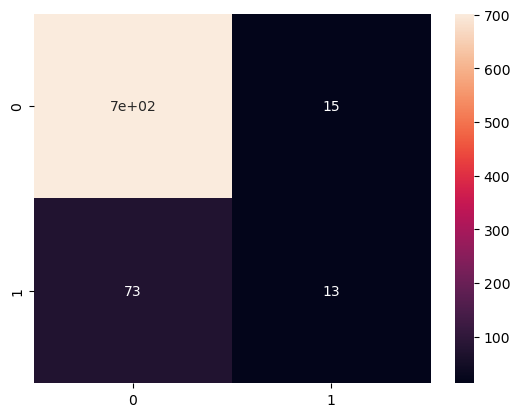

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True)
plt.show()


## Flask ##

In [35]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))
